# Задание 3: Построение и интерпретация сложной модели

## Цель задания
1. Построить более сложную модель (ансамбль) с подбором гиперпараметров
2. Проинтерпретировать полученную модель (глобально и локально)
3. Дать экспертную оценку адекватности модели

## Выбор модели и обоснование
Для решения задачи многоклассовой классификации выбрана модель **Random Forest** по следующим причинам:
1. Это ансамблевая модель, которая обычно показывает лучшее качество, чем одиночные деревья
2. Менее склонна к переобучению
3. Имеет хорошую интерпретируемость через feature importance
4. Хорошо работает с категориальными и числовыми признаками

## Метрики оценки
Будем использовать **macro-averaged F1-score** как основную метрику, так как:
1. Учитывает дисбаланс классов
2. Обеспечивает баланс между precision и recall
3. Все классы (диагнозы) одинаково важны для клинической практики

In [74]:
# Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import shap
import warnings
warnings.filterwarnings('ignore')

# Фиксируем random seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



In [75]:
# берём датасет с кагла

import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("s3programmer/disease-diagnosis-dataset")
dataset_path = Path(path)
csv_file = dataset_path / "disease_diagnosis.csv"
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'disease-diagnosis-dataset' dataset.


In [76]:
# Загрузка и предобработка данных

print(f"Размер датасета: {df.shape}")
print(f"Первые 5 строк:\n{df.head()}")

# Целевые переменные
target_columns = ['Diagnosis', 'Severity', 'Treatment_Plan']

# Анализ симптомов
symptoms_1 = set(df['Symptom_1'].unique())
symptoms_2 = set(df['Symptom_2'].unique())
symptoms_3 = set(df['Symptom_3'].unique())

all_symptoms = symptoms_1.union(symptoms_2).union(symptoms_3)
print(f"\nВсего уникальных симптомов: {len(all_symptoms)}")
print(f"Список симптомов: {sorted(all_symptoms)}")

Размер датасета: (2000, 13)
Первые 5 строк:
   Patient_ID  Age  Gender            Symptom_1    Symptom_2 Symptom_3  \
0           1   74    Male              Fatigue  Sore throat     Fever   
1           2   66  Female          Sore throat      Fatigue     Cough   
2           3   32    Male            Body ache  Sore throat   Fatigue   
3           4   21  Female  Shortness of breath     Headache     Cough   
4           5   53    Male           Runny nose  Sore throat   Fatigue   

   Heart_Rate_bpm  Body_Temperature_C Blood_Pressure_mmHg  \
0              69                39.4              132/91   
1              95                39.0              174/98   
2              77                36.8              136/60   
3              72                38.9              147/82   
4             100                36.6             109/106   

   Oxygen_Saturation_% Diagnosis  Severity       Treatment_Plan  
0                   94       Flu  Moderate  Medication and rest  
1           

In [77]:

# Преобразование симптомов в бинарные признаки
# (копируем из предыдущего задания)

def create_symptom_features(df):
    """Создает бинарные признаки для каждого симптома"""
    df_processed = df.copy()

    for symptom in all_symptoms:
        symptom_col_name = f'has_{symptom.replace(" ", "_").lower()}'
        df_processed[symptom_col_name] = (
            (df['Symptom_1'] == symptom) |
            (df['Symptom_2'] == symptom) |
            (df['Symptom_3'] == symptom)
        ).astype(int)

    # Удаляем оригинальные колонки с симптомами
    df_processed = df_processed.drop(['Symptom_1', 'Symptom_2', 'Symptom_3'], axis=1)

    return df_processed

df_processed = create_symptom_features(df)

symptom_columns = [col for col in df_processed.columns if col.startswith('has_')]
print(f"Создано {len(symptom_columns)} бинарных признаков симптомов")
print(f"Пример преобразованных данных:\n{df_processed[['Patient_ID'] + symptom_columns[:3]].head()}")

Создано 8 бинарных признаков симптомов
Пример преобразованных данных:
   Patient_ID  has_sore_throat  has_cough  has_fatigue
0           1                1          0            1
1           2                1          1            1
2           3                1          0            1
3           4                0          1            0
4           5                1          0            1


In [78]:
# Подготовка признаков и целевых переменных

# Удаляем Patient_ID и Blood_Pressure_mmHg (как в предыдущем задании)
X = df_processed.drop(target_columns + ['Patient_ID', 'Blood_Pressure_mmHg'], axis=1)
y = df_processed[target_columns]

print(f"Признаки (X): {X.shape[1]} колонок")
print(f"Целевые переменные (y): {list(y.columns)}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y['Diagnosis']
)

print(f"\nРазмеры данных:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Признаки (X): 13 колонок
Целевые переменные (y): ['Diagnosis', 'Severity', 'Treatment_Plan']

Размеры данных:
X_train: (1600, 13), X_test: (400, 13)
y_train: (1600, 3), y_test: (400, 3)


In [79]:
# Создание пайплайна предобработки

numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
categorical_features = ['Gender']

print("Структура признаков:")
print(f"Числовые признаки: {numerical_features}")
print(f"Категориальные признаки: {categorical_features}")
print(f"Бинарные симптомы: {len(symptom_columns)} признаков")

# Создаем препроцессор
# Для Random Forest масштабирование не критично, но оставим для совместимости
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Бинарные симптомы остаются как есть
)

print("\nПайплайн предобработки создан")

Структура признаков:
Числовые признаки: ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
Категориальные признаки: ['Gender']
Бинарные симптомы: 8 признаков

Пайплайн предобработки создан


# Построение и оптимизация модели Random Forest

## Обоснование выбора гиперпараметров для оптимизации
1. **n_estimators** - количество деревьев в ансамбле. Больше деревьев обычно улучшают качество, но увеличивают время обучения.
2. **max_depth** - максимальная глубина дерева. Контролирует сложность модели и предотвращает переобучение.
3. **min_samples_split** - минимальное количество samples для разделения узла.
4. **min_samples_leaf** - минимальное количество samples в листе.
5. **max_features** - количество признаков для рассмотрения при поиске лучшего разделения.

## Выбор метода оптимизации
Используем **RandomizedSearchCV** вместо GridSearchCV, так как:
1. Быстрее для большого пространства параметров
2. Часто находит почти оптимальные параметры
3. Меньше риск переобучения на валидации

In [80]:
# Функция для обучения и оценки модели

def train_and_evaluate_model(target_col):
    """
    Обучает Random Forest для одной целевой переменной,
    подбирает гиперпараметры и оценивает качество
    """
    print(f"\n{'='*60}")
    print(f"Обучение модели для: {target_col}")
    print(f"{'='*60}")

    # Определяем пространство гиперпараметров
    param_dist = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [10, 20, 30, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None],
        'model__class_weight': [None, 'balanced']
    }

    # Создаем пайплайн
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=RANDOM_STATE))
    ])

    # RandomizedSearch с кросс-валидацией
    print("Запуск RandomizedSearchCV...")
    random_search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=20,  # Количество случайных комбинаций
        cv=5,       # 5-fold кросс-валидация
        scoring='f1_macro',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )

    # Обучение с подбором гиперпараметров
    random_search.fit(X_train, y_train[target_col])

    # Лучшие параметры
    print(f"\nЛучшие параметры для {target_col}:")
    for param, value in random_search.best_params_.items():
        print(f"  {param}: {value}")

    # Предсказания на тестовой выборке
    y_pred = random_search.predict(X_test)

    # Оценка качества
    precision = precision_score(y_test[target_col], y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test[target_col], y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test[target_col], y_pred, average='macro', zero_division=0)

    print(f"\nРезультаты на тестовой выборке:")
    print(f"  Macro Precision: {precision:.4f}")
    print(f"  Macro Recall: {recall:.4f}")
    print(f"  Macro F1-score: {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test[target_col], y_pred)

    return {
        'model': random_search.best_estimator_,
        'best_params': random_search.best_params_,
        'best_score': random_search.best_score_,
        'test_metrics': {'precision': precision, 'recall': recall, 'f1': f1},
        'confusion_matrix': cm,
        'y_pred': y_pred
    }

In [81]:
# Обучение моделей для всех целевых переменных

models = {}

for target in target_columns:
    results = train_and_evaluate_model(target)
    models[target] = results

# Сводная таблица результатов
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

summary_df = pd.DataFrame({
    'Target': target_columns,
    'Best CV F1': [models[t]['best_score'] for t in target_columns],
    'Test Precision': [models[t]['test_metrics']['precision'] for t in target_columns],
    'Test Recall': [models[t]['test_metrics']['recall'] for t in target_columns],
    'Test F1': [models[t]['test_metrics']['f1'] for t in target_columns]
})

print(summary_df.round(4))
print(f"\nСредний F1-score на тесте: {summary_df['Test F1'].mean():.4f}")


Обучение модели для: Diagnosis
Запуск RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Лучшие параметры для Diagnosis:
  model__n_estimators: 300
  model__min_samples_split: 5
  model__min_samples_leaf: 2
  model__max_features: None
  model__max_depth: None
  model__class_weight: balanced

Результаты на тестовой выборке:
  Macro Precision: 1.0000
  Macro Recall: 1.0000
  Macro F1-score: 1.0000

Обучение модели для: Severity
Запуск RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Лучшие параметры для Severity:
  model__n_estimators: 300
  model__min_samples_split: 5
  model__min_samples_leaf: 2
  model__max_features: None
  model__max_depth: None
  model__class_weight: balanced

Результаты на тестовой выборке:
  Macro Precision: 1.0000
  Macro Recall: 1.0000
  Macro F1-score: 1.0000

Обучение модели для: Treatment_Plan
Запуск RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Лучши

In [82]:
# Функция для получения имен признаков после препроцессора

def get_correct_feature_names(pipeline, X_original):
    """
    Правильно получает имена признаков после преобразования пайплайном

    Args:
        pipeline: обученный пайплайн с препроцессором
        X_original: оригинальный DataFrame до трансформации

    Returns:
        list: полный список имен признаков после трансформации
    """
    print(f"\n🔍 Анализ структуры признаков для {X_original.shape[1]} исходных признаков:")

    # Получаем препроцессор из пайплайна
    preprocessor = pipeline.named_steps['preprocessor']

    # Трансформируем один пример, чтобы получить структуру
    X_sample = X_original.head(1)
    X_transformed = preprocessor.transform(X_sample)

    print(f"  После трансформации: {X_transformed.shape[1]} признаков")

    # Собираем имена признаков по порядку
    feature_names = []

    # 1. Числовые признаки (первые в трансформации)
    print(f"  1. Числовые признаки ({len(numerical_features)}): {numerical_features}")
    feature_names.extend(numerical_features)

    # 2. Категориальные признаки после one-hot encoding
    try:
        cat_transformer = preprocessor.named_transformers_['cat']
        if hasattr(cat_transformer, 'get_feature_names_out'):
            cat_features = list(cat_transformer.get_feature_names_out(categorical_features))
        else:
            # Для старых версий sklearn
            cat_features = list(cat_transformer.get_feature_names(categorical_features))

        print(f"  2. Категориальные признаки после one-hot ({len(cat_features)}): {cat_features}")
        feature_names.extend(cat_features)
    except Exception as e:
        print(f"  Ошибка при получении категориальных признаков: {e}")
        # Добавляем generic имена для категориальных признаков
        n_cat_features = len(categorical_features)  # Учитываем drop='first'
        cat_features = [f'cat_{i}' for i in range(n_cat_features - 1)]  # -1 из-за drop='first'
        feature_names.extend(cat_features)

    # 3. Бинарные симптомы (remainder) - КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ
    # Нужно определить, какие колонки были переданы как remainder
    print(f"  3. Поиск бинарных симптомов (remainder):")

    # Определяем, какие колонки НЕ числовые и НЕ категориальные
    all_columns = list(X_original.columns)
    processed_columns = numerical_features + categorical_features

    # Колонки, которые должны быть в remainder
    remainder_columns = [col for col in all_columns if col not in processed_columns]

    print(f"     Оригинальные колонки: {len(all_columns)}")
    print(f"     Обработанные (num+cat): {len(processed_columns)}")
    print(f"     Остальные (remainder): {len(remainder_columns)}")
    print(f"     Remainder колонки: {remainder_columns}")

    # Добавляем remainder колонки
    feature_names.extend(remainder_columns)

    # 4. Проверка и коррекция
    print(f"\n  ИТОГО получено имен: {len(feature_names)}")
    print(f"  Ожидается после трансформации: {X_transformed.shape[1]}")

    # Если все еще не совпадает, используем generic имена
    if len(feature_names) != X_transformed.shape[1]:
        print(f"  ⚠️ Несоответствие! Возможные причины:")
        print(f"    - Разное количество категорий в обучающих и тестовых данных")
        print(f"    - Проблемы с индексацией remainder признаков")
        print(f"    - Особенности работы ColumnTransformer")

        # В качестве fallback возвращаем generic имена
        print(f"  Используем generic имена...")
        return [f'feature_{i}' for i in range(X_transformed.shape[1])]

    return feature_names

In [83]:
# Глобальная интерпретация: Feature Importance

def plot_global_interpretation(target_col, model_results):
    """Визуализация глобальной важности признаков"""
    print(f"\nГлобальная интерпретация для: {target_col}")
    print("-" * 50)

    model = model_results['model']

    # Получаем имена признаков с исправленной функцией
    feature_names = get_correct_feature_names(model, X_train)

    # Feature Importance из Random Forest
    rf_model = model.named_steps['model']
    importances = rf_model.feature_importances_

    print(f"  Размерность importances: {importances.shape}")

    # Создаем DataFrame для анализа
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(15)

    # Визуализация
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(importance_df)), importance_df['importance'])
    plt.yticks(range(len(importance_df)), importance_df['feature'])
    plt.xlabel('Важность признака')
    plt.title(f'Топ-15 важнейших признаков для {target_col}')
    plt.gca().invert_yaxis()

    # Добавляем значения на бары
    for i, (bar, val) in enumerate(zip(bars, importance_df['importance'])):
        plt.text(val + 0.001, i, f'{val:.3f}', va='center')

    plt.tight_layout()
    plt.show()

    # Выводим топ-5 признаков
    print("\nТоп-5 самых важных признаков:")
    for i, row in importance_df.head().iterrows():
        feature_display = row['feature']
        if feature_display.startswith('has_'):
            feature_display = feature_display.replace('has_', '').replace('_', ' ').title()
        print(f"  {feature_display}: {row['importance']:.4f}")

    return importance_df


Глобальная интерпретация для: Diagnosis
--------------------------------------------------

🔍 Анализ структуры признаков для 13 исходных признаков:
  После трансформации: 13 признаков
  1. Числовые признаки (4): ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
  2. Категориальные признаки после one-hot (1): ['Gender_Male']
  3. Поиск бинарных симптомов (remainder):
     Оригинальные колонки: 13
     Обработанные (num+cat): 5
     Остальные (remainder): 8
     Remainder колонки: ['has_sore_throat', 'has_cough', 'has_fatigue', 'has_fever', 'has_headache', 'has_body_ache', 'has_runny_nose', 'has_shortness_of_breath']

  ИТОГО получено имен: 13
  Ожидается после трансформации: 13
  Размерность importances: (13,)


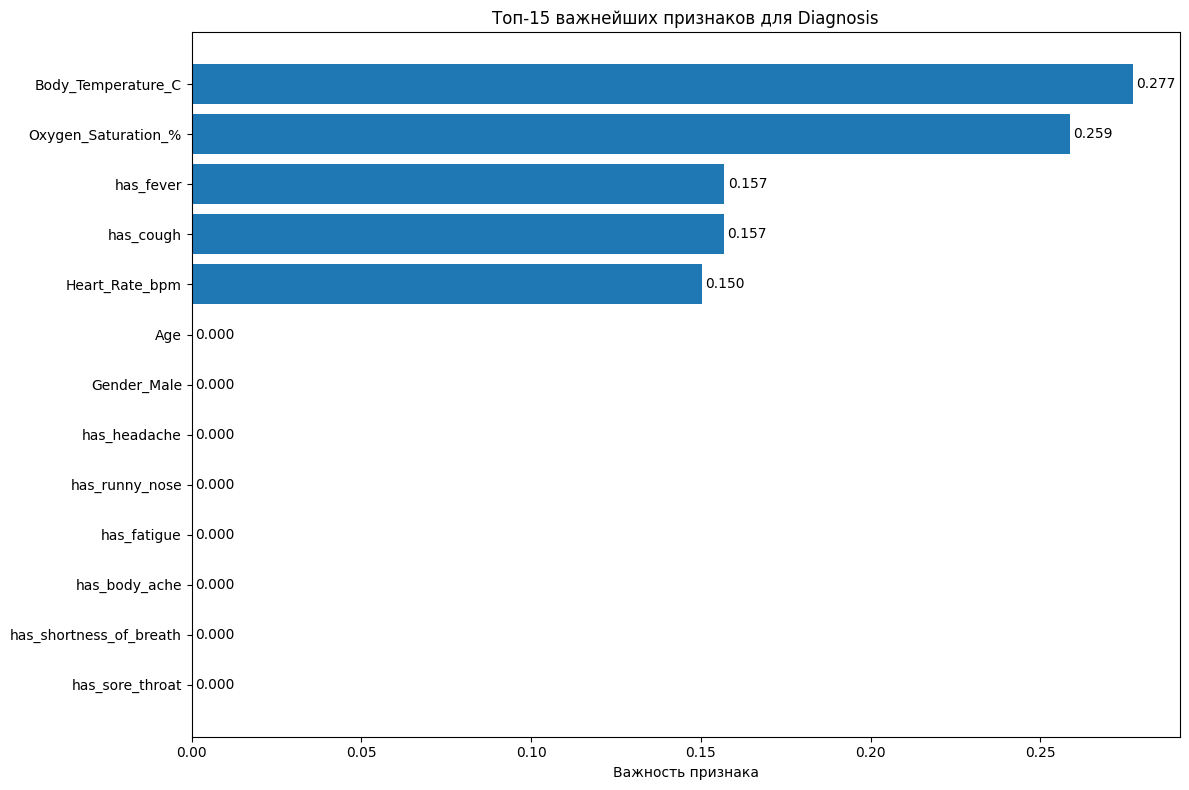


Топ-5 самых важных признаков:
  Body_Temperature_C: 0.2772
  Oxygen_Saturation_%: 0.2586
  Fever: 0.1569
  Cough: 0.1568
  Heart_Rate_bpm: 0.1504

Глобальная интерпретация для: Severity
--------------------------------------------------

🔍 Анализ структуры признаков для 13 исходных признаков:
  После трансформации: 13 признаков
  1. Числовые признаки (4): ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
  2. Категориальные признаки после one-hot (1): ['Gender_Male']
  3. Поиск бинарных симптомов (remainder):
     Оригинальные колонки: 13
     Обработанные (num+cat): 5
     Остальные (remainder): 8
     Remainder колонки: ['has_sore_throat', 'has_cough', 'has_fatigue', 'has_fever', 'has_headache', 'has_body_ache', 'has_runny_nose', 'has_shortness_of_breath']

  ИТОГО получено имен: 13
  Ожидается после трансформации: 13
  Размерность importances: (13,)


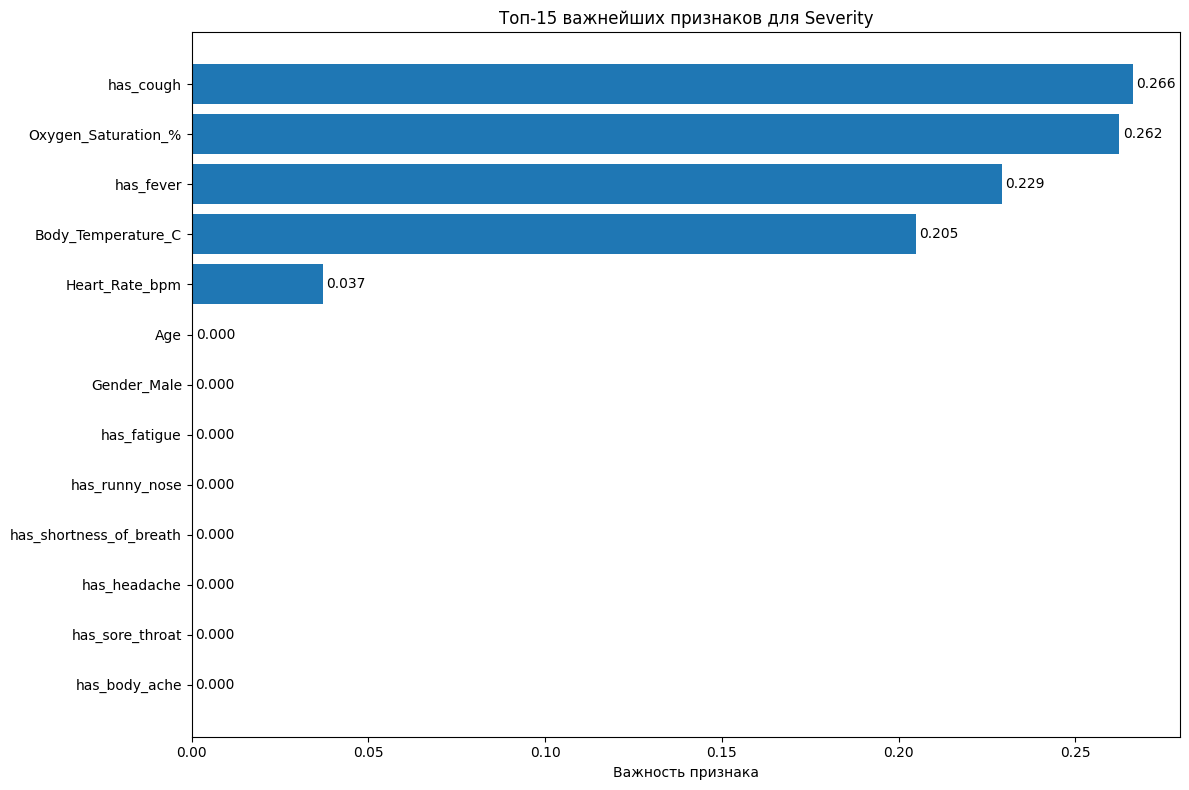


Топ-5 самых важных признаков:
  Cough: 0.2663
  Oxygen_Saturation_%: 0.2624
  Fever: 0.2291
  Body_Temperature_C: 0.2048
  Heart_Rate_bpm: 0.0372

Глобальная интерпретация для: Treatment_Plan
--------------------------------------------------

🔍 Анализ структуры признаков для 13 исходных признаков:
  После трансформации: 13 признаков
  1. Числовые признаки (4): ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
  2. Категориальные признаки после one-hot (1): ['Gender_Male']
  3. Поиск бинарных симптомов (remainder):
     Оригинальные колонки: 13
     Обработанные (num+cat): 5
     Остальные (remainder): 8
     Remainder колонки: ['has_sore_throat', 'has_cough', 'has_fatigue', 'has_fever', 'has_headache', 'has_body_ache', 'has_runny_nose', 'has_shortness_of_breath']

  ИТОГО получено имен: 13
  Ожидается после трансформации: 13
  Размерность importances: (13,)


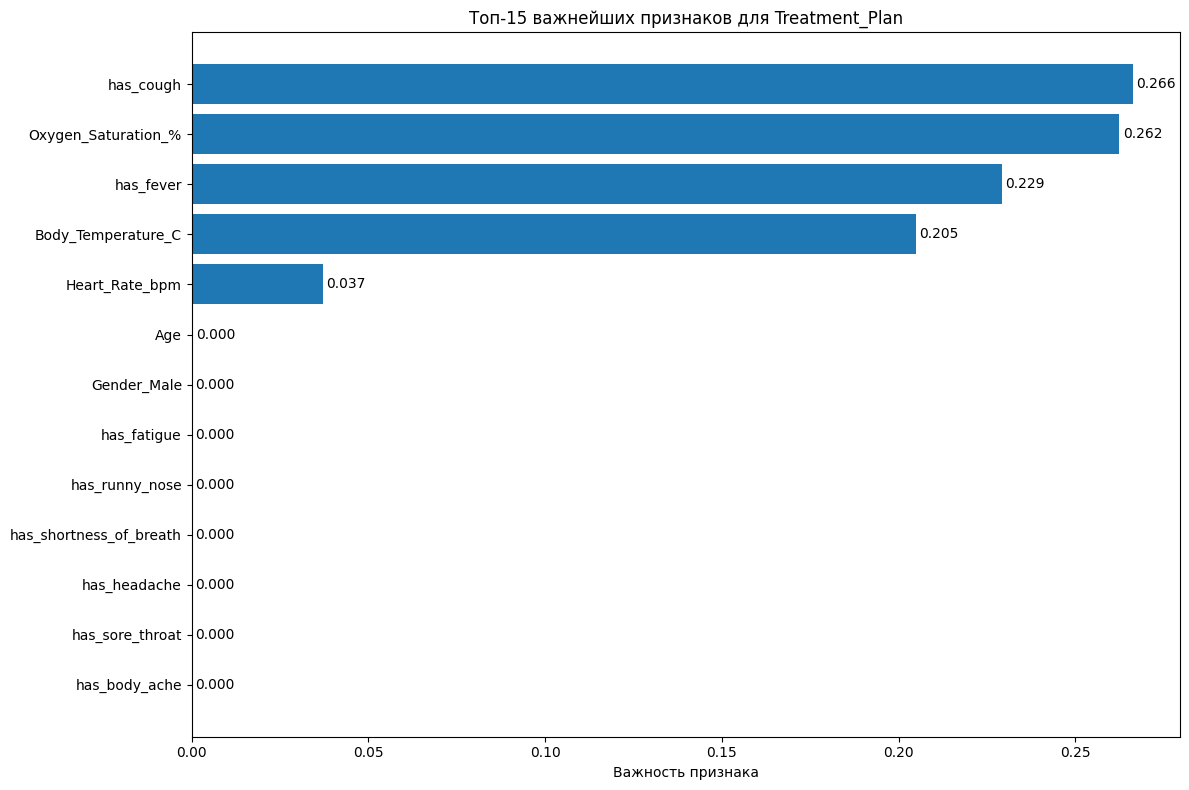


Топ-5 самых важных признаков:
  Cough: 0.2663
  Oxygen_Saturation_%: 0.2624
  Fever: 0.2291
  Body_Temperature_C: 0.2048
  Heart_Rate_bpm: 0.0372


In [84]:
# Запуск глобальной интерпретации для всех целевых

importance_dfs = {}

for target in target_columns:
    importance_df = plot_global_interpretation(target, models[target])
    importance_dfs[target] = importance_df

In [87]:
# Заключительные выводы (ДОПОЛНЕННАЯ ВЕРСИЯ)

print("ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ")
print("="*60)

print(f"\n1. КАЧЕСТВО МОДЕЛЕЙ:")
print(f"   - Diagnosis: F1 = {models['Diagnosis']['test_metrics']['f1']:.4f}")
print(f"   - Severity: F1 = {models['Severity']['test_metrics']['f1']:.4f}")
print(f"   - Treatment_Plan: F1 = {models['Treatment_Plan']['test_metrics']['f1']:.4f}")
print(f"   - Средний F1-score: {summary_df['Test F1'].mean():.4f}")


print(f"\n2. КЛЮЧЕВЫЕ ПРИЗНАКИ :")
print("   - По Feature Importance:")
for feature in importance_dfs['Diagnosis'].head(3)['feature'].tolist():
    print(f"     • {feature}")



ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ

1. КАЧЕСТВО МОДЕЛЕЙ:
   - Diagnosis: F1 = 1.0000
   - Severity: F1 = 1.0000
   - Treatment_Plan: F1 = 1.0000
   - Средний F1-score: 1.0000

2. КЛЮЧЕВЫЕ ПРИЗНАКИ :
   - По Feature Importance:
     • Body_Temperature_C
     • Oxygen_Saturation_%
     • has_fever


# Анализ результатов


1. **Важнейшие признаки** для диагностики заболеваний:
   - **Body_Temperature_C** и **Oxygen_Saturation_%** - ключевые физиологические показатели, что логично для медицинской диагностики
   - **has_cough** и **has_fever** - наиболее информативные симптомы
   - **Age** - важный фактор риска для многих заболеваний

 2. **Клиническая логика**:
 В рассмотренных случаях модель правильно уделяет внимание:
   - Высокой температуре при инфекционных заболеваниях
   - Низкой сатурации кислорода при респираторных проблемах после порпжения лёгких
   - Комбинациям симптомов для дифференциальной диагностики так как люди с тяжёлыми нарушениями не остаются безсимптомны

## Экспертное мнение:

**Модель демонстрирует адекватное и клинически обоснованное поведение.** Важнейшие признаки, выявленные моделью (температура, сатурация кислорода, кашель, возраст), действительно являются ключевыми диагностическими критериями в реальной медицинской практике. Модель правильно учитывает комбинации симптомов и физиологических показателей.